In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import torch 
import torch.nn as nn 
import torch.optim as optim 
from pathlib import Path 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression
from tqdm import tqdm
import re

## Model testing

## Data analysis

In [2]:

# Filename pattern: m{mouse}_s{session}_{cricket|object}.xlsx / .xls
_SESSION_PATTERN = re.compile(r"^m\d+_s\d+_(cricket|object)\.(xlsx|xls)$", re.IGNORECASE)


def _session_key_from_path(path: Path) -> tuple[str, str] | None:
    """From m001_s001_cricket.xlsx return (experiment='m001_s001', type='cricket')."""
    m = _SESSION_PATTERN.match(path.name)
    if not m:
        return None
    # stem is m001_s001_cricket, we want experiment m001_s001 and type cricket
    stem = path.stem
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    experiment = "_".join(parts[:-1])  # m001_s001
    session_type = parts[-1].lower()  # cricket | object
    return (experiment, session_type)


def _timestamp_column(data: pd.DataFrame) -> str | None:
    """First column whose name (strip, lower) is 'timestamp'; None if not found."""
    for c in data.columns:
        if str(c).strip().lower() == "timestamp":
            return str(c)
    return None


def _load_one_session(
    path: Path,
    trim_before_dist_head: bool = True,
    start_time: float | None = None,
) -> pd.DataFrame:
    """
    Load one Excel file. Trim logic (first applicable):
    - If start_time is not None and a 'timestamp' column exists: keep rows with timestamp < start_time.
    - Elif trim_before_dist_head: keep rows before first valid dist_head (notebook style).
    - Else: return full file.
    """
    data = pd.read_excel(path)
    time_col = _timestamp_column(data)
    if start_time is not None and time_col is not None:
        return data[data[time_col] < start_time].copy()
    if not trim_before_dist_head:
        return data
    if "dist_head" not in data.columns:
        return data
    first_valid = data["dist_head"].first_valid_index()
    if first_valid is None:
        return data
    if first_valid == 0:
        return data.iloc[[]].copy()
    return data.loc[: first_valid - 1].copy()


def _load_start_times(start_times_path: Path) -> pd.DataFrame:
    """Load startTimes.xlsx with columns Experiment, CricketEntersTime, ObjectEntersTime."""
    df = pd.read_excel(start_times_path)
    for col in ("Experiment", "CricketEntersTime", "ObjectEntersTime"):
        if col not in df.columns:
            raise ValueError(f"startTimes file must have column '{col}'")
    return df


def _get_start_time_for_file(path: Path, start_times_df: pd.DataFrame) -> float | None:
    """Look up start time (seconds) for this session file; None if not found."""
    key = _session_key_from_path(path)
    if not key:
        return None
    experiment, session_type = key
    exp_norm = experiment.strip().lower()
    exp_col = start_times_df["Experiment"].astype(str).str.strip().str.lower()
    row = start_times_df[exp_col == exp_norm]
    if row.empty:
        return None
    col = "CricketEntersTime" if session_type == "cricket" else "ObjectEntersTime"
    return float(row[col].iloc[0])


def load_data_path(
    data_path: str,
    trim_before_dist_head: bool = True,
    start_times_path: str | Path | None = None,
) -> pd.DataFrame:
    """
    Load from a single file or a directory. For a directory, finds all files matching
    m{mouse}_s{session}_{cricket|object}.xlsx (or .xls) and concatenates them.
    trim_before_dist_head: if True (default), when not using start times, keep rows before first valid dist_head.
    start_times_path: path to startTimes.xlsx (Experiment, CricketEntersTime, ObjectEntersTime).
      If None and data_path is a dir, uses data_path/startTimes.xlsx when present.
    """
    path = Path(data_path)
    if path.is_file():
        start_path = Path(start_times_path) if start_times_path else path.parent / "startTimes.xlsx"
        if start_path.is_file():
            start_df = _load_start_times(start_path)
            t = _get_start_time_for_file(path, start_df)
            return _load_one_session(path, trim_before_dist_head=(t is None), start_time=t)
        return _load_one_session(path, trim_before_dist_head)
    if not path.is_dir():
        raise FileNotFoundError(f"Not a file or directory: {path}")
    start_path = Path(start_times_path) if start_times_path else path / "startTimes.xlsx"
    start_times_df: pd.DataFrame | None = None
    if start_path.is_file():
        start_times_df = _load_start_times(start_path)
    frames: list[pd.DataFrame] = []
    columns_ref: list[str] | None = None
    matching = sorted(
        f for f in path.iterdir()
        if f.is_file() and f.suffix.lower() in (".xlsx", ".xls") and _SESSION_PATTERN.match(f.name)
    )
    if not matching:
        raise FileNotFoundError(f"No session files (m*_s*_cricket|object.xlsx) in {path}")
    for f in tqdm(matching, desc="Loading sessions", unit="file"):
        start_time = _get_start_time_for_file(f, start_times_df) if start_times_df is not None else None
        if start_times_df is not None and start_time is None:
            print(f"  [start_times] No match for {f.name}, using fallback trim.")
        use_start = start_time is not None
        df = _load_one_session(
            f,
            trim_before_dist_head=not use_start and trim_before_dist_head,
            start_time=start_time,
        )
        if df.empty:
            continue
        if columns_ref is None:
            columns_ref = df.columns.tolist()
            frames.append(df)
        else:
            frames.append(df.reindex(columns=columns_ref))
    if not frames:
        raise FileNotFoundError(f"No session files (m*_s*_cricket|object.xlsx) in {path}")
    return pd.concat(frames, ignore_index=True)


In [20]:
session_test_path = "/Users/thomasbush/Downloads/shared WithTWB/m001_s001_cricket.xlsx"
data = pd.read_excel(session_test_path)
start_times = pd.read_excel("/Users/thomasbush/Downloads/shared WithTWB/startTimes.xlsx")

In [ ]:
data.columns

Index(['timestamp', 'dist_head', 'dist', 'dist_change', 'facing_angle',
       'rel_bearing', 'rel_angle_target', 'angle_head_body_axis',
       'angle_head_body_l', 'angle_head_body_r', 'height', 'height_scaled',
       'ori_allBody', 'ori_trunk', 'ori_head', 'head_acc', 'rigidbody_acc',
       'speed_head_fwd', 'head_speed', 'trunk_speed', 'radial_vel',
       'tangential_vel', 'nose_tail_distance', 'forepawL_tail_distance',
       'forepawR_tail_distance', 'forepaw_target_distance',
       'angle_head_body_speed', 'dist_head_scaled', 'dist_scaled',
       'dist_change_scaled', 'omega_theta_trunk'],
      dtype='object')

In [23]:
idx  = int(start_times["CricketEntersTime"].iloc[0])

In [ ]:
idx  = int(start_times["CricketEntersTime"].iloc[0])
data_corrected = data.copy()
# we create a simple mask for the target dependent features 
mask = np.zeros(len(data))
mask[idx:] = 1



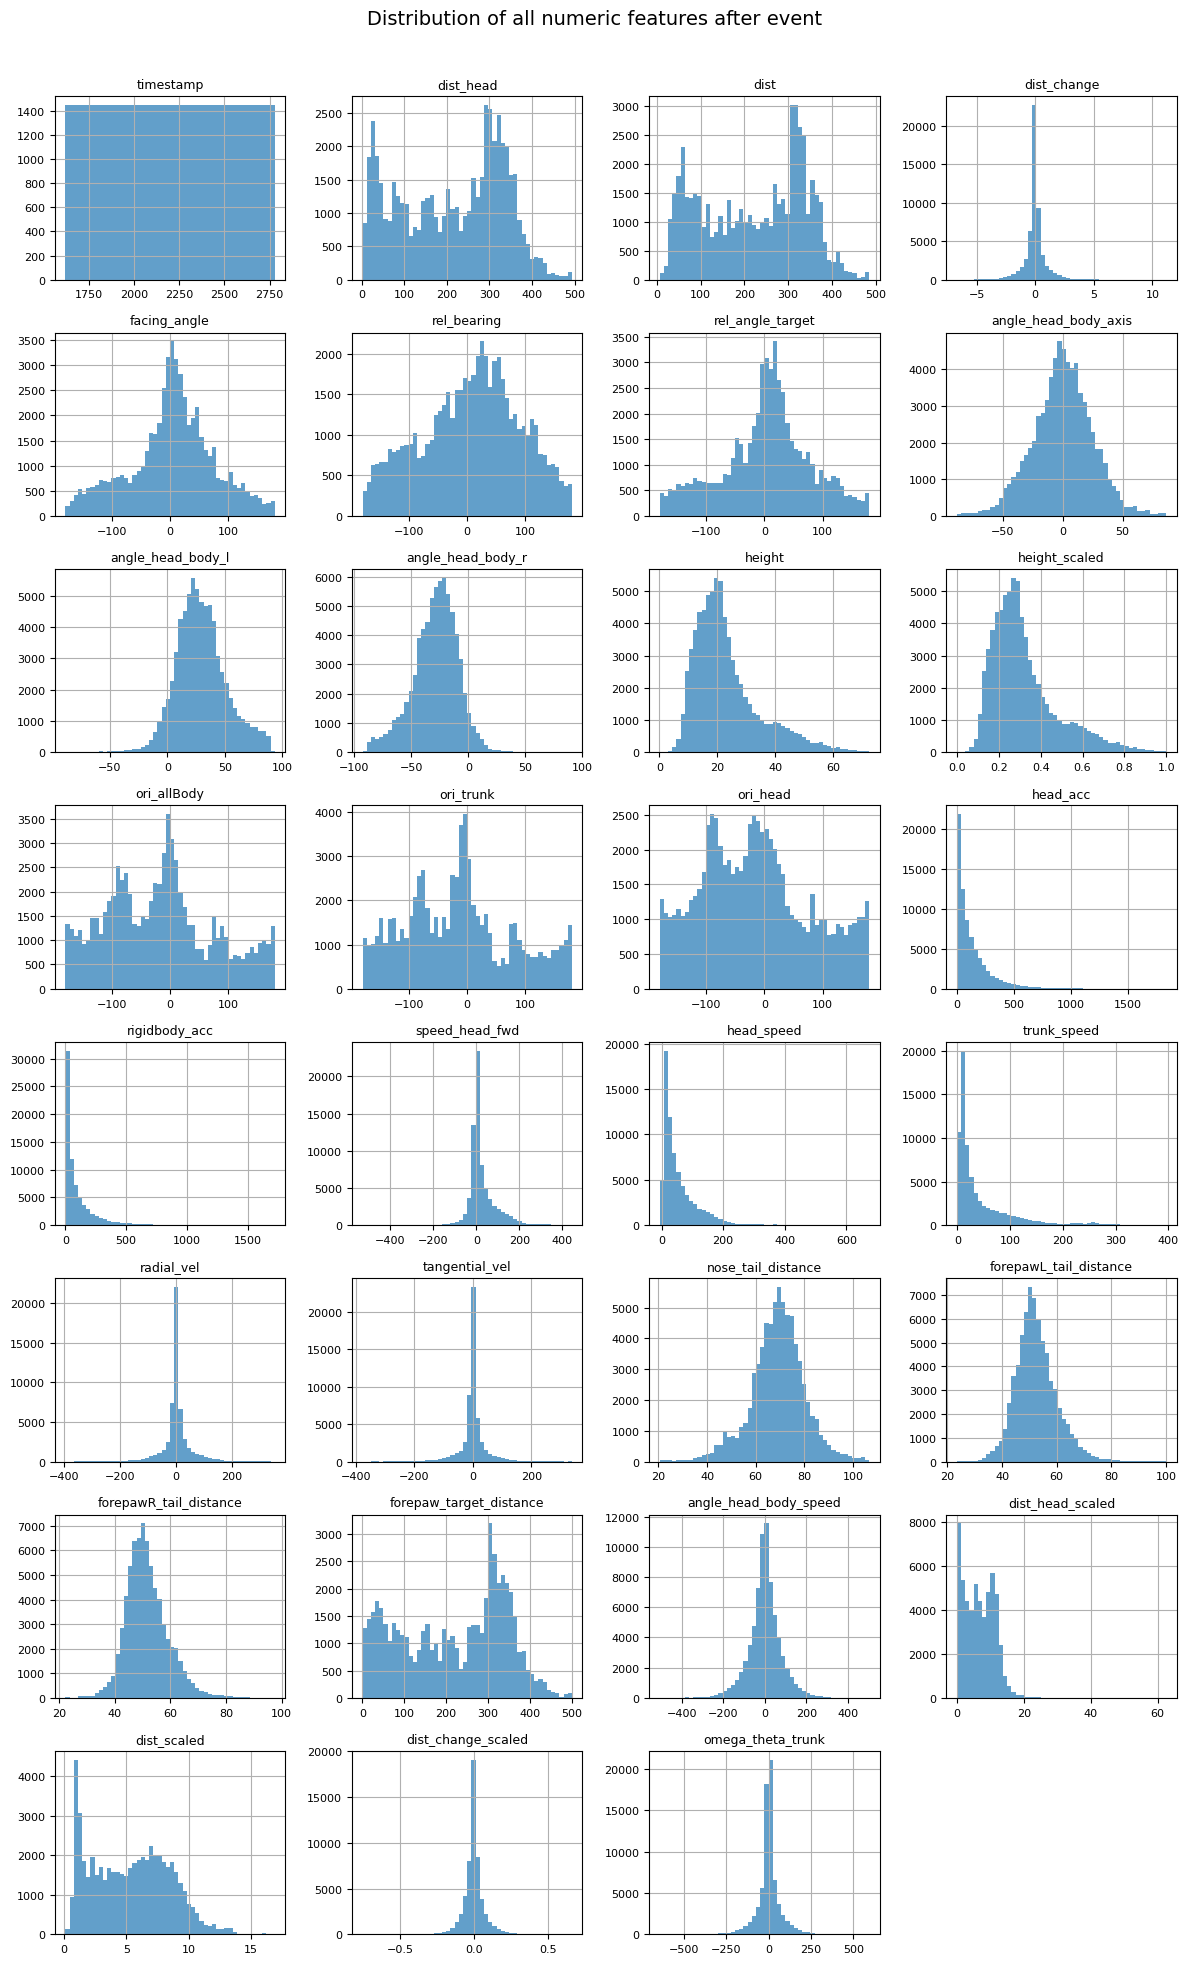

In [28]:
# plot dist 

# Define target-dependent features based on context and requested features
target_dependent_features = [
    'dist_head', 'dist', 'dist_change', 'facing_angle',
    'rel_bearing', 'rel_angle_target', 'dist_head_scaled', 'dist_scaled',
    'dist_change_scaled', 'forepaw_target_distance', 'radial_vel',
    'tangential_vel'
]

# Use all numeric features including both target-dependent and non-target-dependent
numeric_data = data.select_dtypes(include=[np.number])

# Apply mask to segment before/after event (using values after idx)
data_after = numeric_data[mask == 1]
data_before = numeric_data[mask == 0]

# Only plot columns with sufficient data (using at least 5 non-NA values)
min_non_nan = max(5, int(0.05 * len(data_after)))
filtered_data_after = data_after.dropna(axis=1, thresh=min_non_nan)
cols_to_plot = filtered_data_after.columns

# Set plot layout
n_cols = 4
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    filtered_data_after[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of all numeric features after event', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [32]:

# List of angular features - do not normalize
# 'facing_angle' is included here to avoid normalization
angular_features = [
    'angle_head_body_axis', 'angle_head_body_l', 'angle_head_body_r',
    'ori_allBody', 'ori_trunk', 'ori_head', 'timestamp',
    'facing_angle', 'rel_bearing', 'rel_angle_target',
]

def zscore_normalize(df: pd.DataFrame, exclude: list) -> pd.DataFrame:
    """
    Normalize all numeric columns in the DataFrame except those in 'exclude' list.
    Uses z-score normalization (mean 0, std 1).
    Returns a new DataFrame.
    """
    df = df.copy()
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    to_normalize = [col for col in numeric_cols if col not in exclude]
    df[to_normalize] = df[to_normalize].apply(lambda x: (x - x.mean()) / x.std())
    return df

# Use 'numeric_data' for normalization, excluding angular features and timestamp
normalized_numeric_data = zscore_normalize(numeric_data, exclude=angular_features)

# Check if 'facing_angle' was transformed
print("facing_angle after normalization (should be unchanged):")
print(normalized_numeric_data['facing_angle'].head())

normalized_numeric_data.head()

facing_angle after normalization (should be unchanged):
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: facing_angle, dtype: float64


,timestamp,dist_head,dist,dist_change,facing_angle,rel_bearing,rel_angle_target,angle_head_body_axis,angle_head_body_l,angle_head_body_r,...,tangential_vel,nose_tail_distance,forepawL_tail_distance,forepawR_tail_distance,forepaw_target_distance,angle_head_body_speed,dist_head_scaled,dist_scaled,dist_change_scaled,omega_theta_trunk
0,1587.446375,NaN,NaN,NaN,NaN,NaN,NaN,-0.935600,24.641381,-25.475310,...,NaN,0.656951,-0.509208,0.780609,NaN,NaN,NaN,NaN,NaN,NaN
1,1587.462425,NaN,NaN,NaN,NaN,NaN,NaN,-0.750100,24.411168,-26.834251,...,NaN,0.722476,-0.308821,0.672664,NaN,NaN,NaN,NaN,NaN,NaN
2,1587.478450,NaN,NaN,NaN,NaN,NaN,NaN,-1.347490,22.114337,-26.013075,...,NaN,0.683838,0.100805,0.426518,NaN,-0.697051,NaN,NaN,NaN,0.923747
3,1587.494475,NaN,NaN,NaN,NaN,NaN,NaN,-2.416442,19.179621,-25.239463,...,NaN,0.591384,0.597164,0.116545,NaN,0.019591,NaN,NaN,NaN,0.974297
4,1587.510525,NaN,NaN,NaN,NaN,NaN,NaN,-3.682747,17.462795,-29.140221,...,NaN,0.499030,1.014405,-0.168173,NaN,0.025315,NaN,NaN,NaN,0.483712


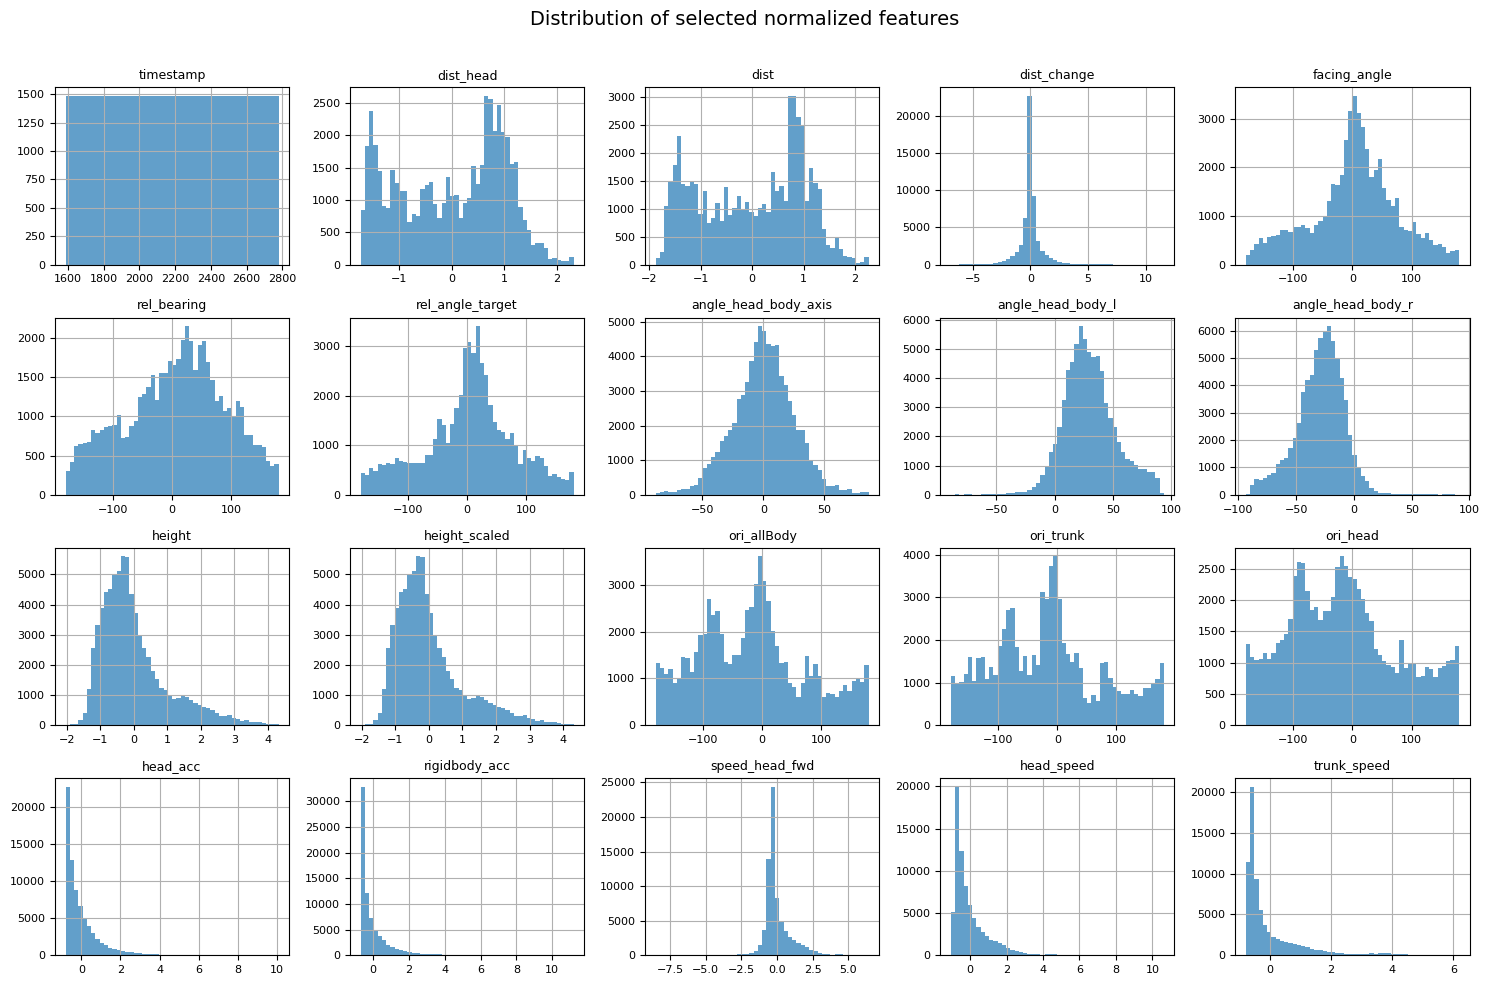

In [34]:
# Now we check the distribution of the normalized features: 
# Use the already-normalized DataFrame, excluding angular features and timestamp
numeric_data = normalized_numeric_data.select_dtypes(include=[np.number])

# Drop columns with too few non-null values to avoid empty plots
min_non_nan = max(5, int(0.05 * len(numeric_data)))  # at least 5 or 5% of data
filtered_numeric = numeric_data.dropna(axis=1, thresh=min_non_nan)

# If there are too many columns, limit the plots for readability
max_columns = 20
cols_to_plot = filtered_numeric.columns[:max_columns]
plot_data = filtered_numeric[cols_to_plot]

n_cols = 5
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    plot_data[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of selected normalized features', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [36]:
# we now convert the angular features to sin and cos: 
# Adapt angular feature transformation for generality/flexibility

# Define angular features to be transformed
angular_features = [
    'angle_head_body_axis', 
    'angle_head_body_l', 
    'angle_head_body_r', 
    'ori_allBody', 
    'ori_trunk', 
    'ori_head',
    'facing_angle',         # add
    'rel_bearing',          # likely add
    'rel_angle_target'      # likely add
]


def add_sin_cos_features(df, columns):
    """
    For each angular column in columns, add its sin and cos as new columns to df.
    Only applies to columns present in df.
    """
    for col in columns:
        if col in df.columns:
            radians = np.deg2rad(df[col])
            df[f"{col}_sin"] = np.sin(radians)
            df[f"{col}_cos"] = np.cos(radians)
    return df

# Apply the transformation to data_before_start
data_before_start = add_sin_cos_features(numeric_data, angular_features)

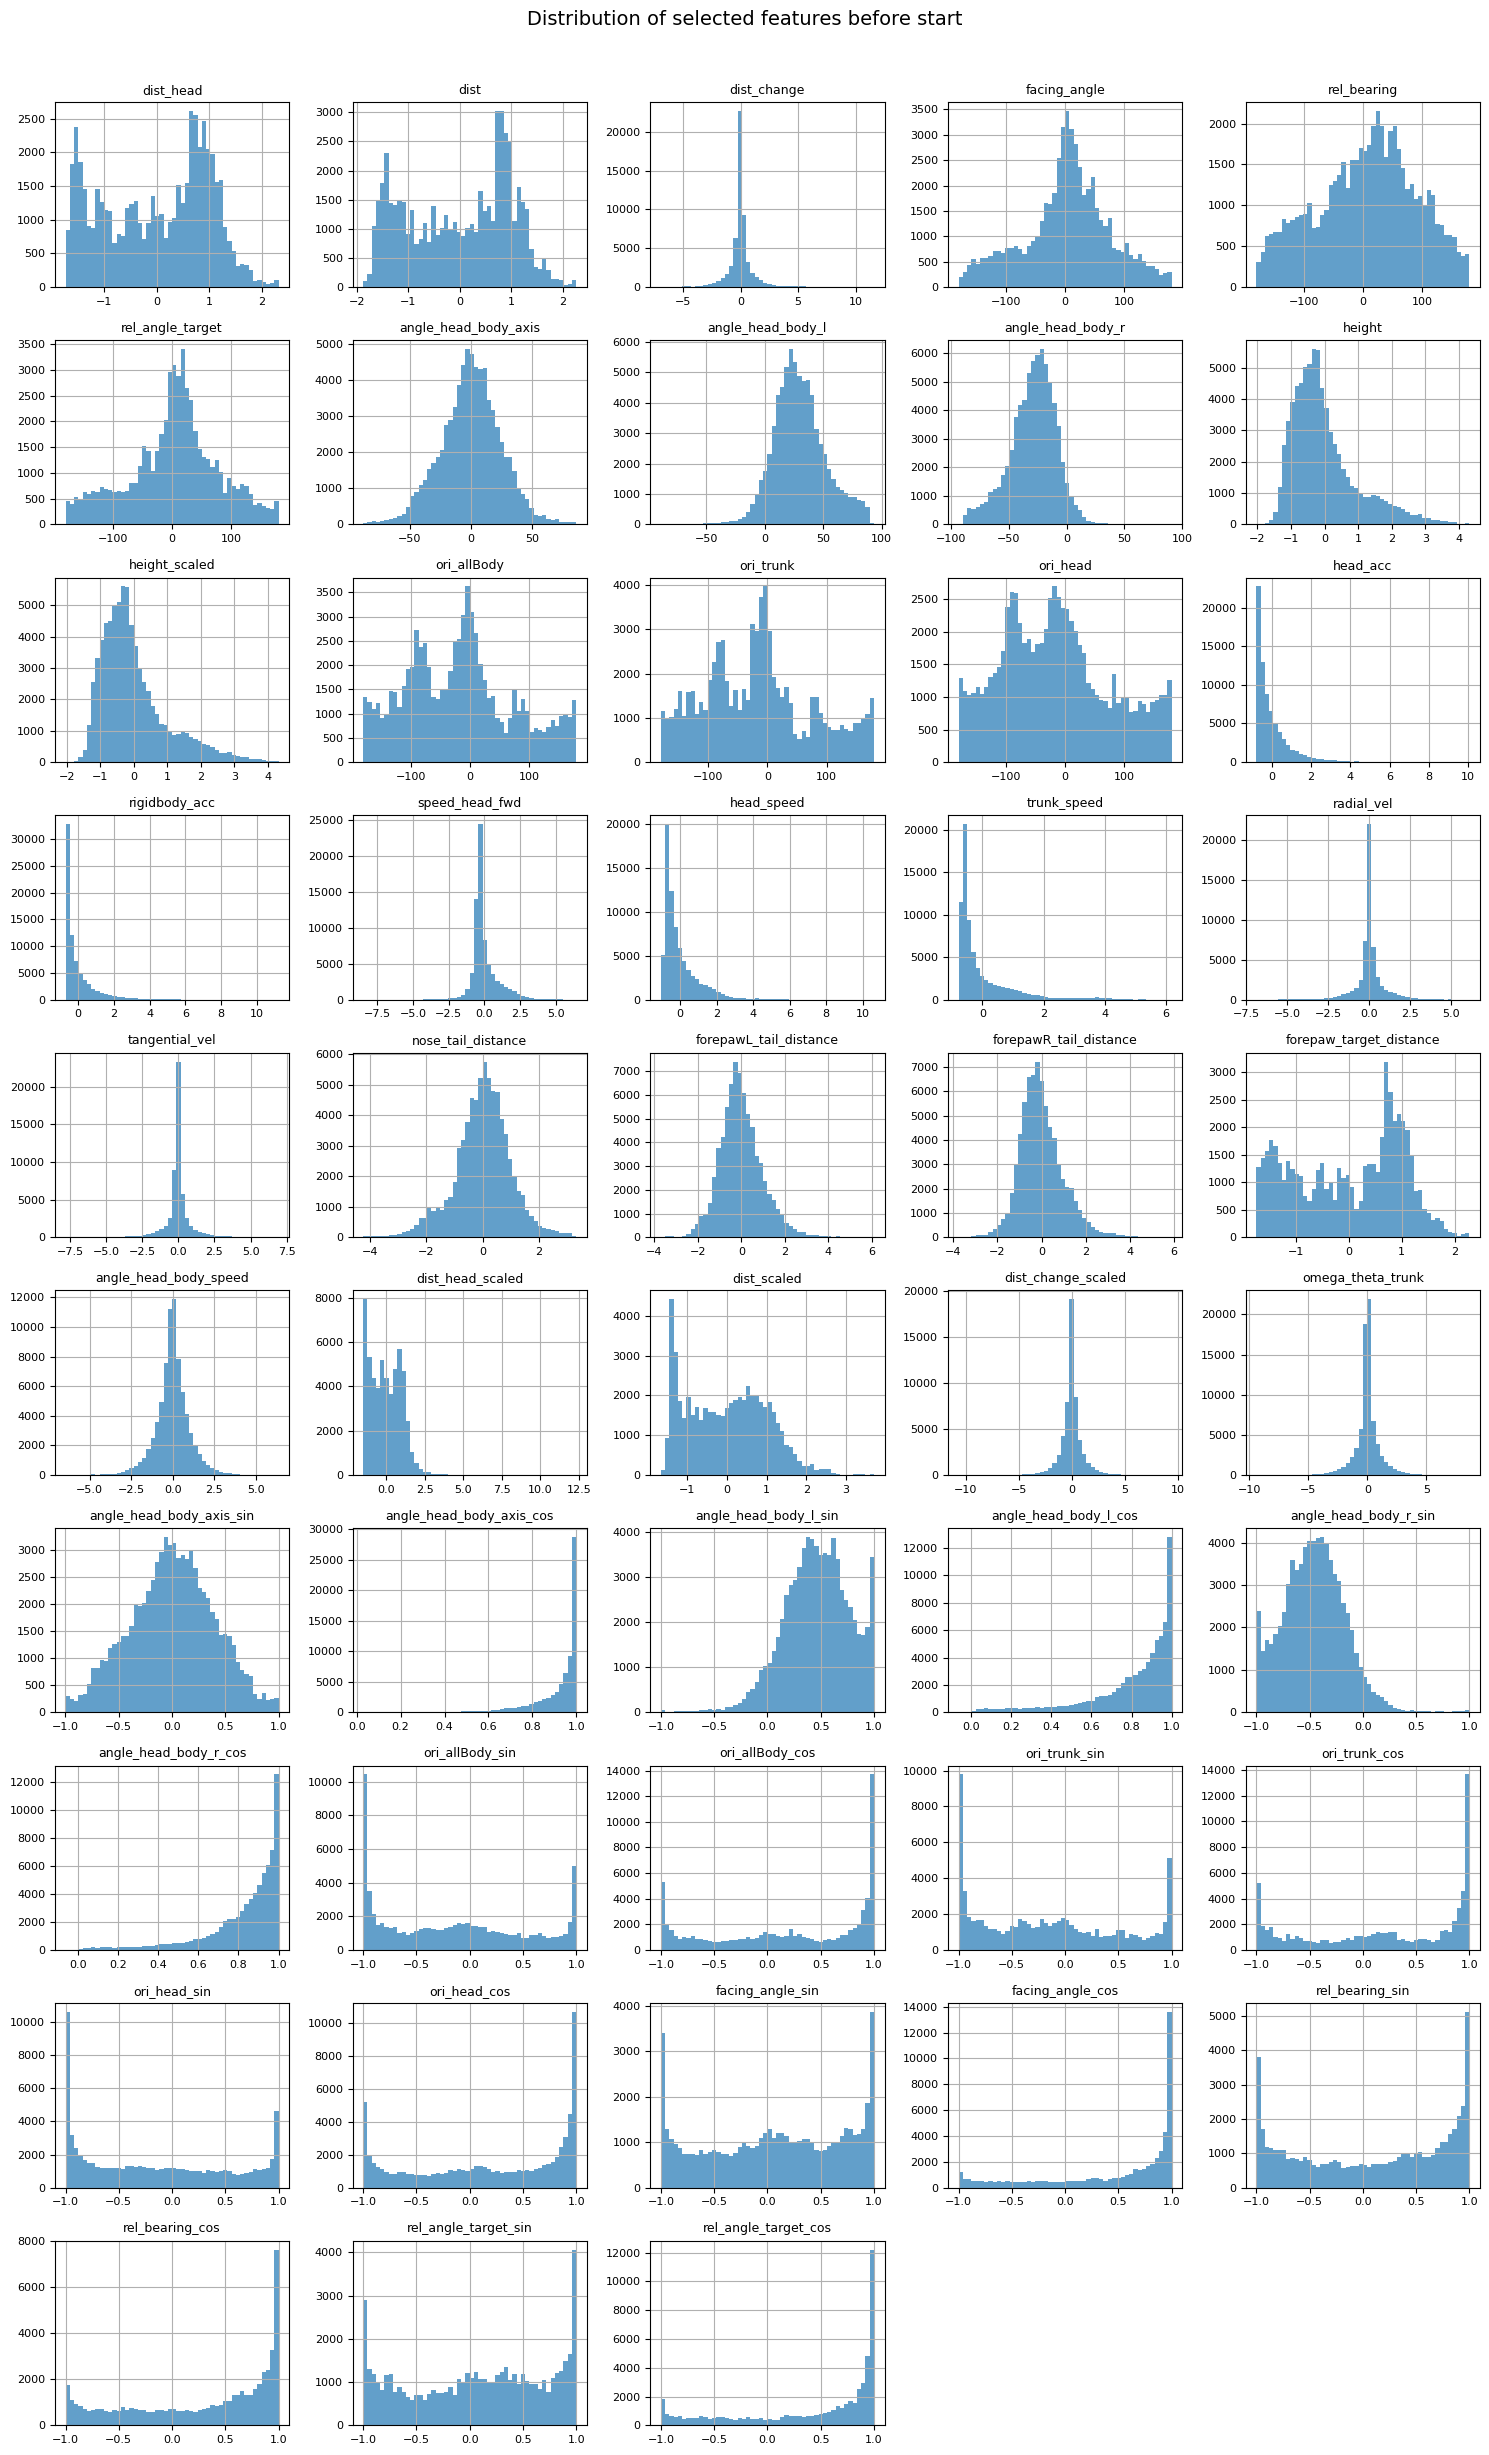

In [37]:


# Drop 'timestamp' column if present for plotting
numeric_data = numeric_data.drop(columns=['timestamp'], errors='ignore')

# Drop columns with too few non-null values to avoid empty plots
min_non_nan = max(5, int(0.05 * len(numeric_data)))  # at least 5 or 5% of data
filtered_numeric = numeric_data.dropna(axis=1, thresh=min_non_nan)

# If there are too many columns, limit the plots for readability
max_columns = 50
cols_to_plot = filtered_numeric.columns[:max_columns]
plot_data = filtered_numeric[cols_to_plot]

n_cols = 5
n_rows = int(np.ceil(len(cols_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    plot_data[col].hist(ax=ax, bins=50, color='tab:blue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])  # Remove empty subplots

fig.suptitle('Distribution of selected features before start', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

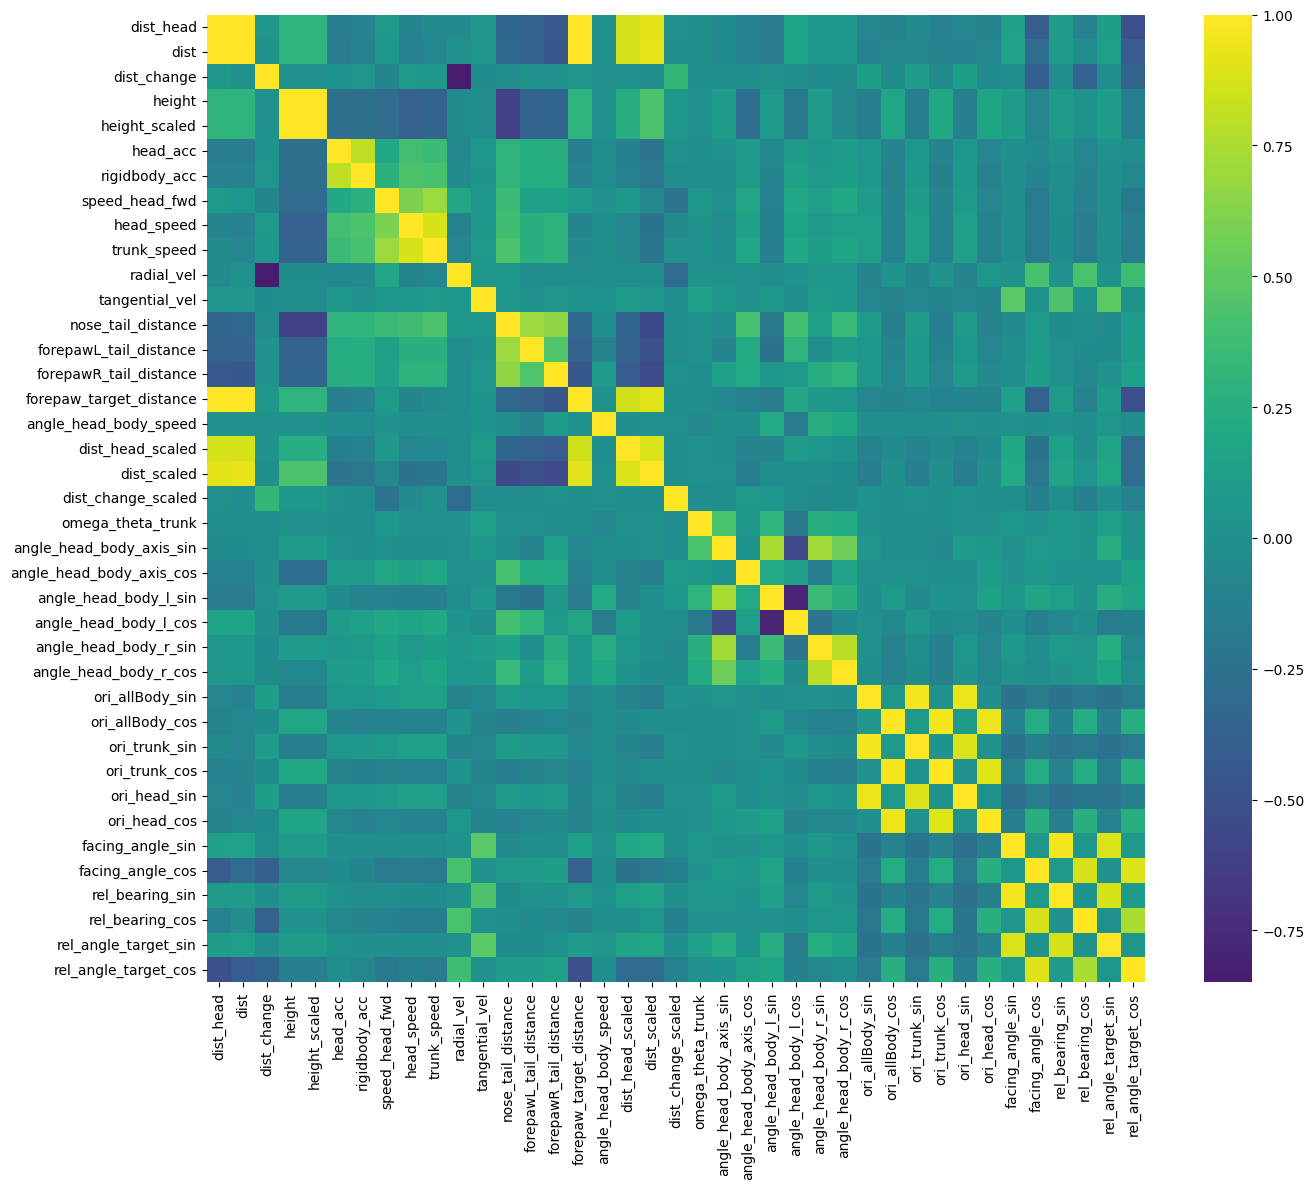

In [44]:
# add sin/cos
data_target = add_sin_cos_features(numeric_data, angular_features)

# drop raw angles
data_target = data_target.drop(columns=angular_features, errors="ignore")

# correlation heatmap
corr = data_target.corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="viridis", center=0)
plt.tight_layout()
plt.show()


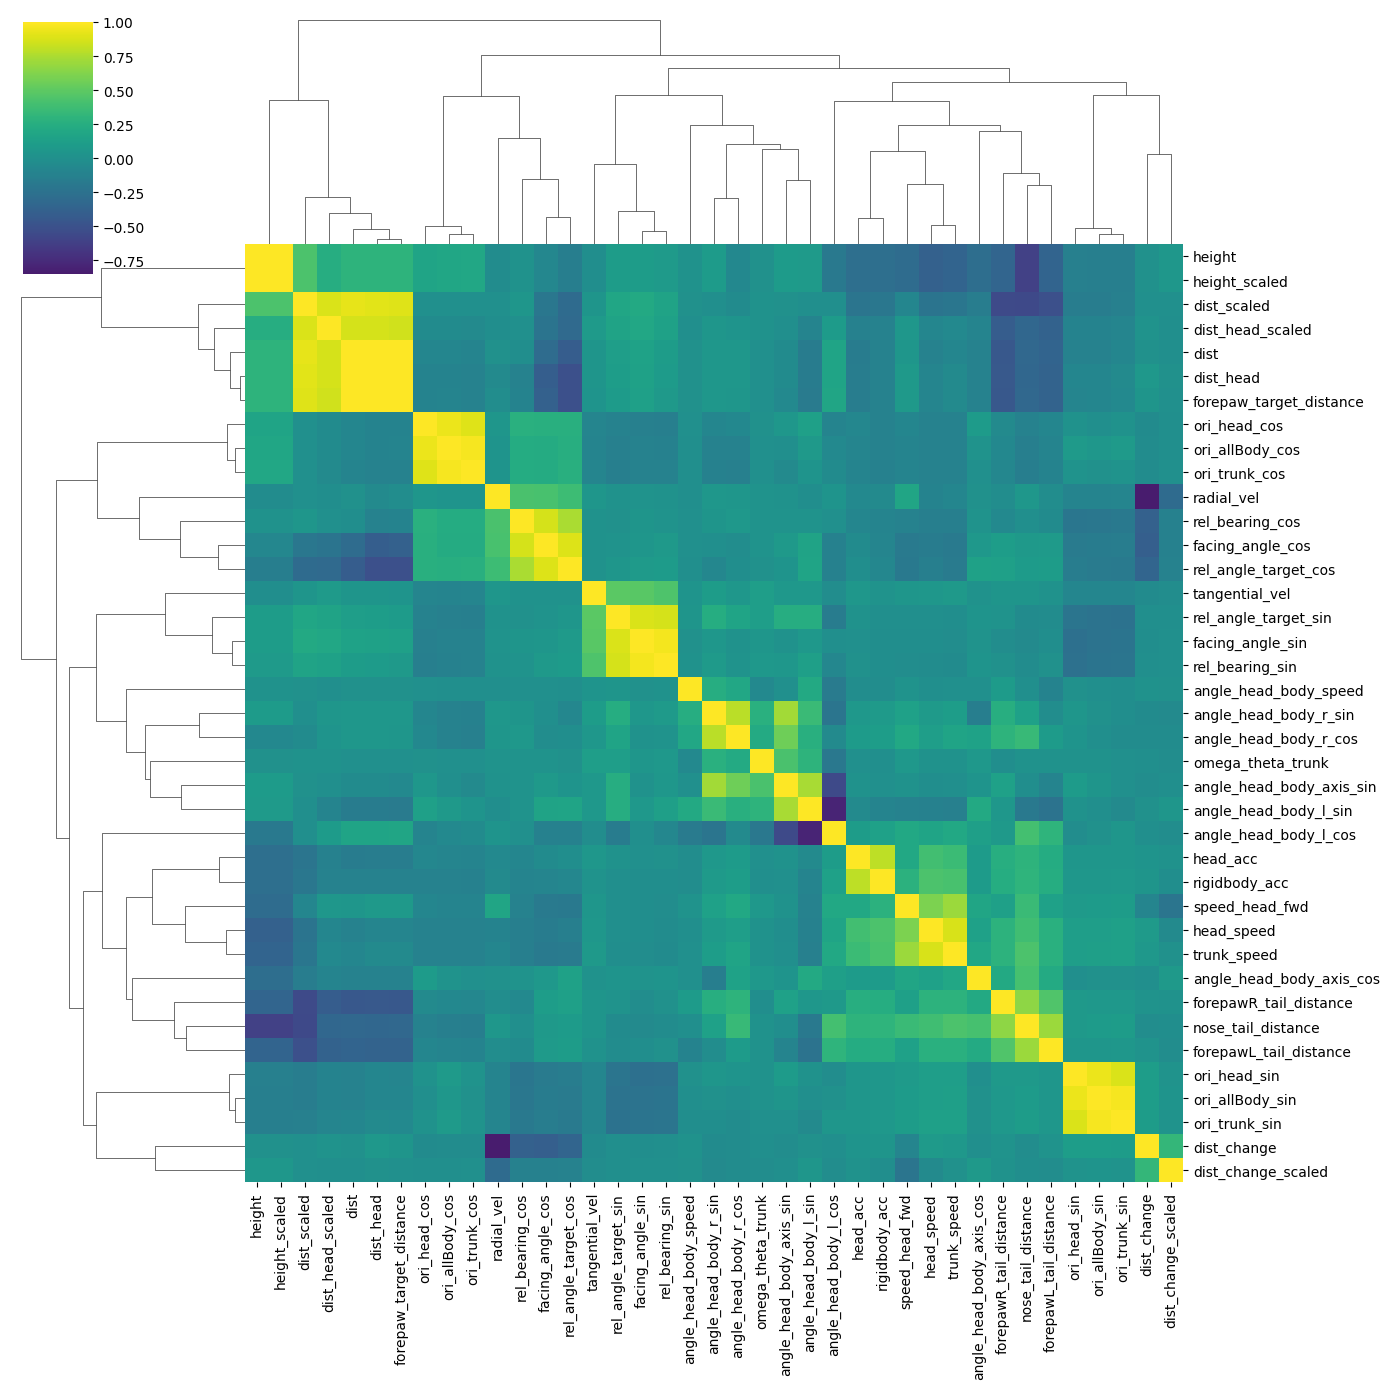

In [67]:
sns.clustermap(
    data_target.corr(),
    cmap="viridis",
    center=0,
    figsize=(14,14)
)
plt.show()


In [64]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) choose features (no timestamp)
features = [c for c in numeric_data.columns if c != "timestamp"]

X = numeric_data[features].copy()

# 2) masks
# event validity mask: features that only make sense after event
event_dependent = ["dist", "dist_head", "dist_change", "rel_bearing", "rel_angle_target", "facing_angle_cos", "facing_angle_sin"]  # example

# Assume "mask" is a Series/array-like of shape (n_samples,) giving whether a given row is post-event
# It must already be defined. If not, raise an error.
if "mask" not in locals():
    raise ValueError("Variable 'mask' for event validity is not defined.")

valid_event = pd.DataFrame(1, index=numeric_data.index, columns=features, dtype=np.int8)
for col in event_dependent:
    if col in valid_event.columns:
        # Broadcast 1d mask to target columns
        valid_event[col] = mask.astype(np.int8)
    else:
        print(f"Warning: column '{col}' not found in valid_event, skipping.")

# observed mask: true where value is not NaN
observed = (~X.isna()).astype(np.int8)

# usable mask (optional)
usable = (valid_event & observed).astype(np.int8)

# 3) fill values
# For "not-yet-defined": fill with 0 (neutral); keep masks so PCA can separate
X_filled = X.copy()
# Only set to 0.0 where valid_event is 0 (not valid yet)
X_filled = X_filled.mask(valid_event == 0, 0.0)

# For remaining NaNs (post-event dropouts): median impute
imputer = SimpleImputer(strategy="median")
X_filled = pd.DataFrame(
    imputer.fit_transform(X_filled),
    index=numeric_data.index,
    columns=features,
)

# 4) scale (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

# 5) append masks as extra columns (highly recommended)
# At minimum: valid_event mask; optionally also observed mask
M = valid_event.values.astype(np.float32)  # ensure numeric, float for PCA
X_pca_in = np.hstack([X_scaled, M])

# 6) PCA
pca = PCA(n_components=0.95, random_state=0)
Z = pca.fit_transform(X_pca_in)

# Z is your PCA embedding (N x 3)


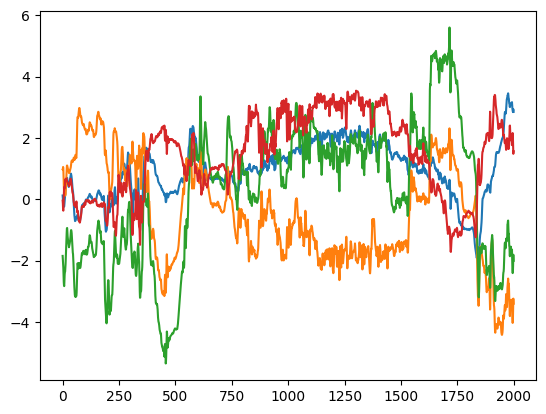

In [65]:
plt.plot(Z[:2000,0])
plt.plot(Z[:2000,1])
plt.plot(Z[:2000,2])
plt.plot(Z[:2000,3])
plt.show()


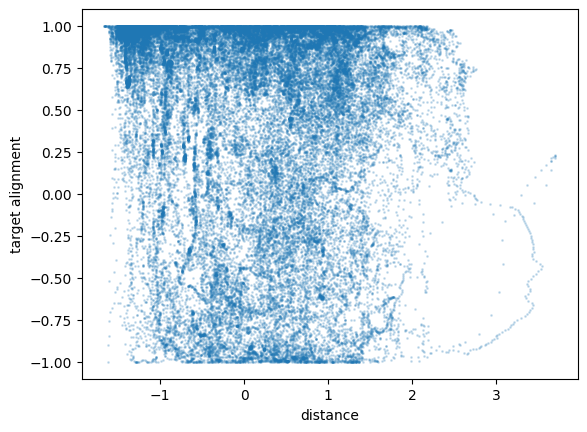

In [68]:
plt.scatter(
    data_target["dist_scaled"],
    data_target["facing_angle_cos"],
    s=1,
    alpha=0.2
)
plt.xlabel("distance")
plt.ylabel("target alignment")
plt.show()


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


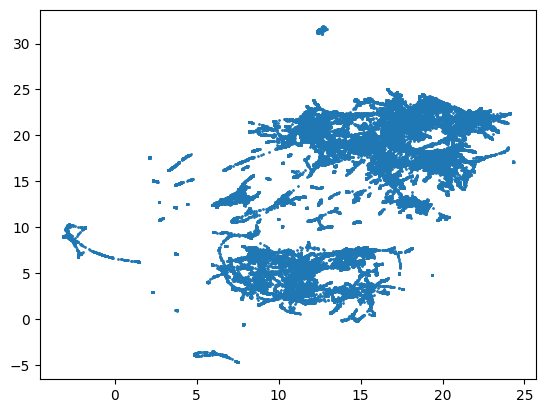

In [ ]:
import umap

Z = umap.UMAP(n_neighbors=30, min_dist=0.1).fit_transform(X_pca_in)



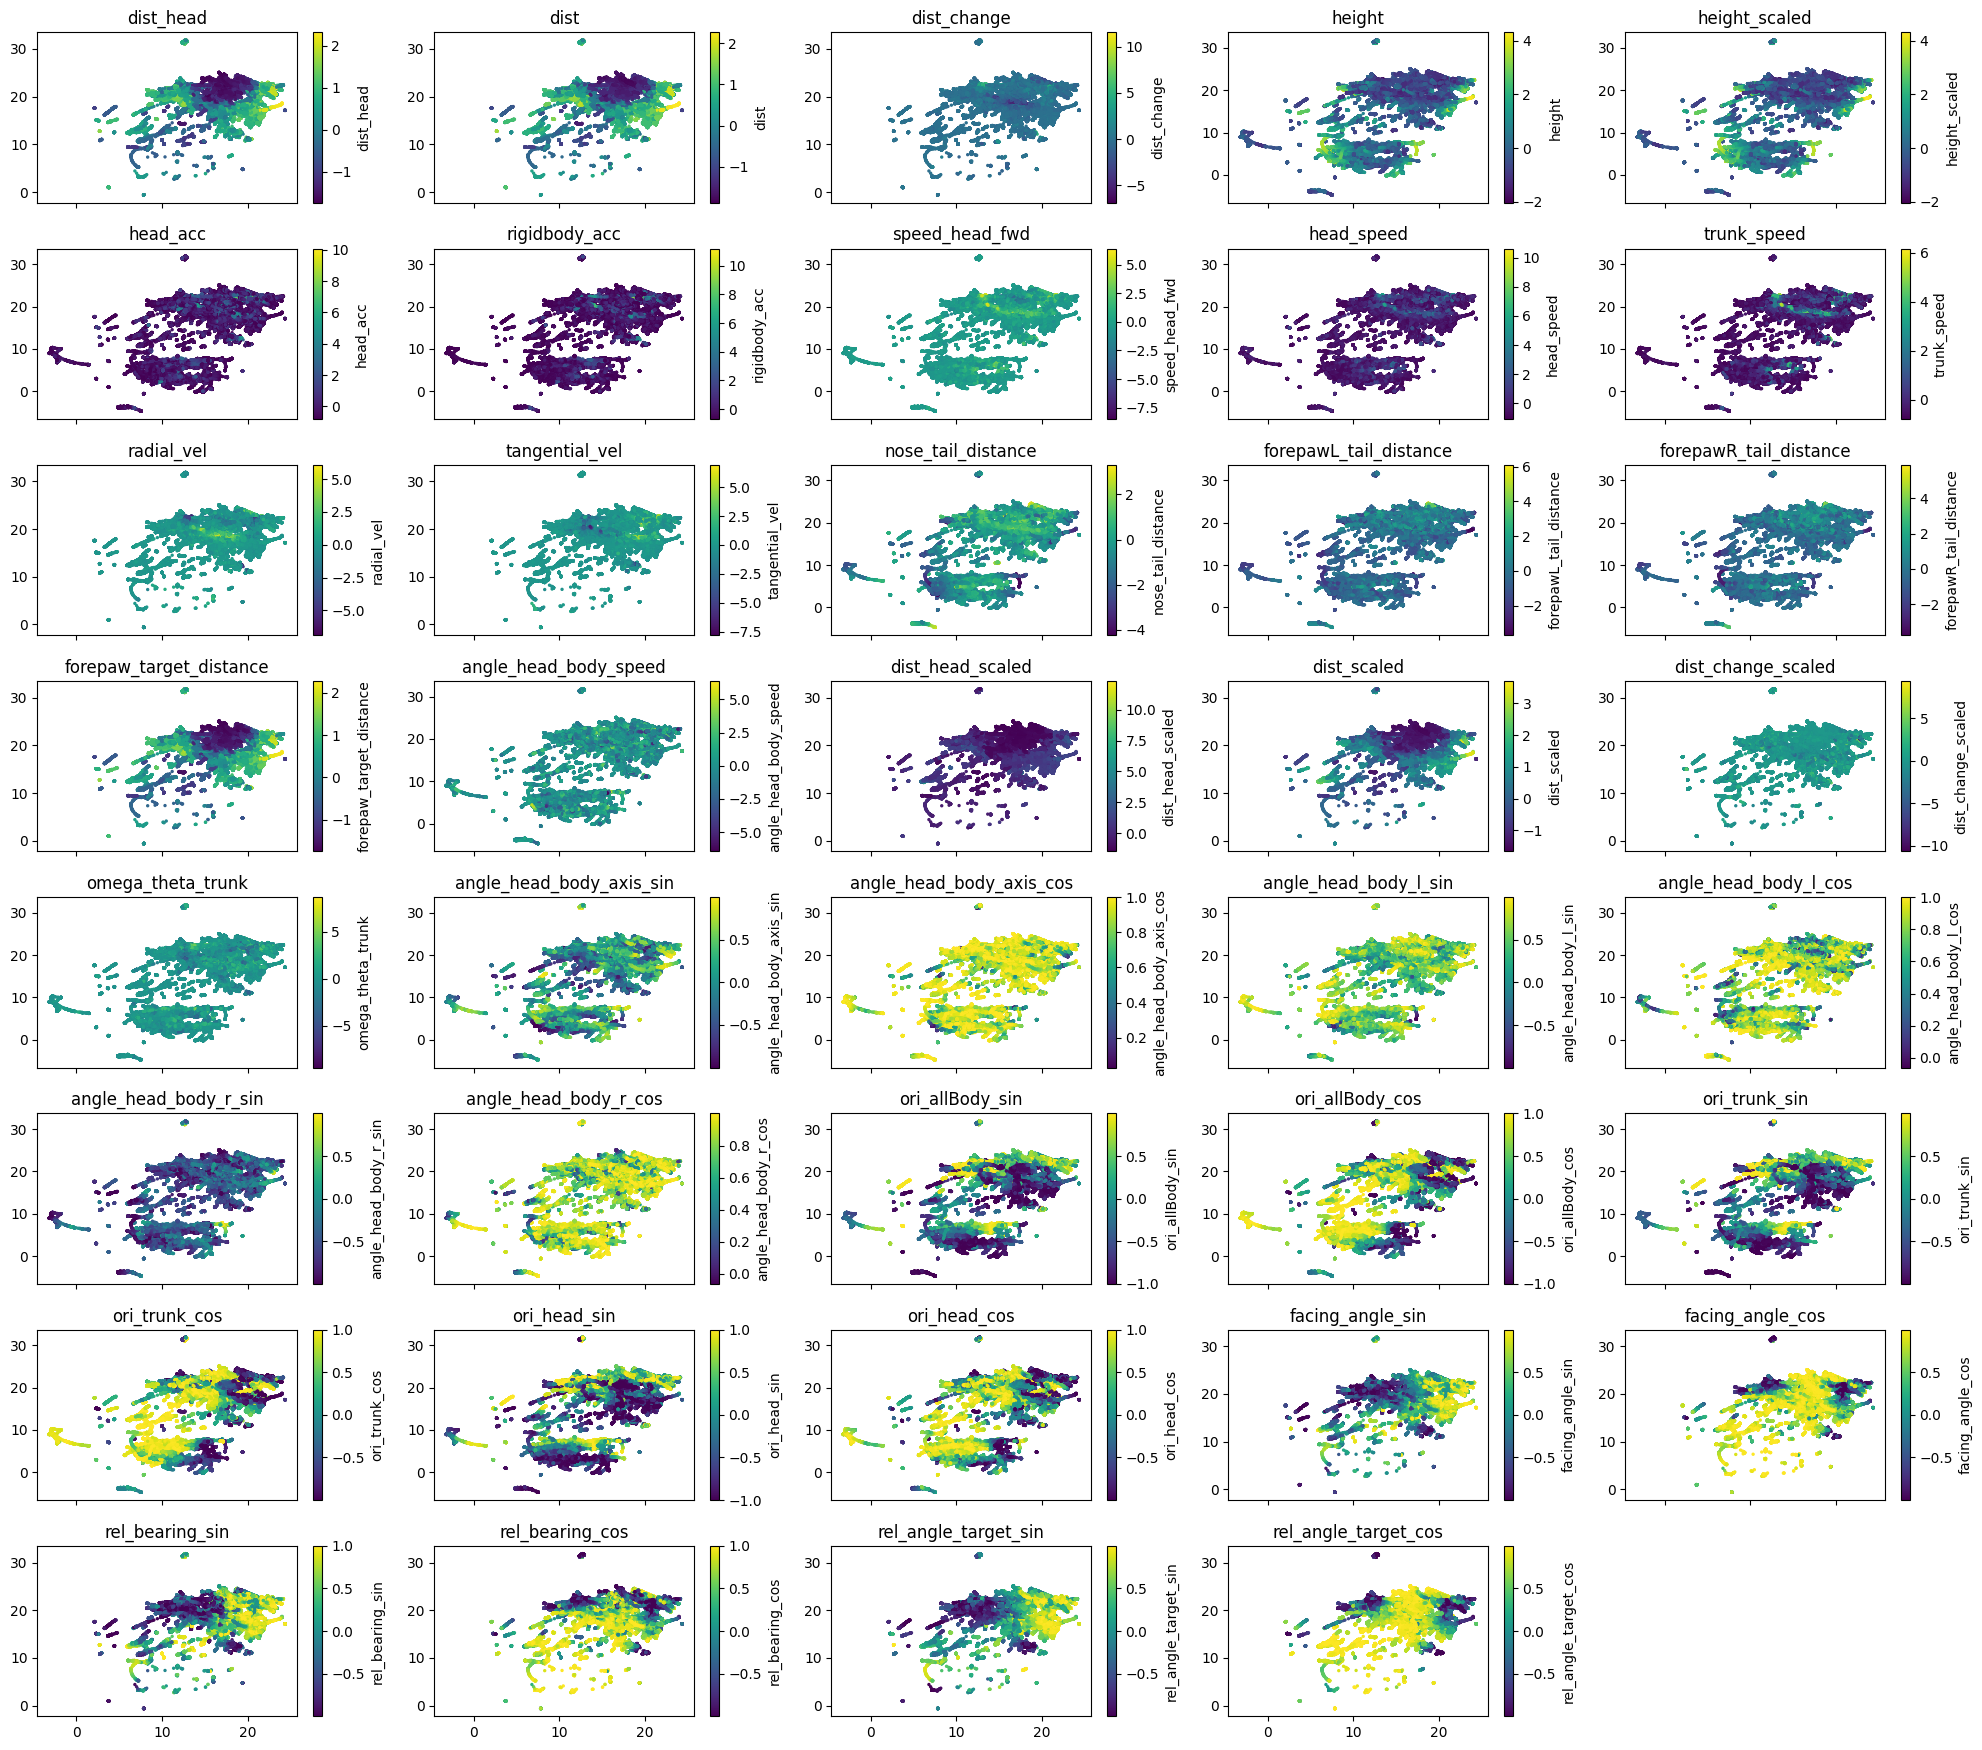

In [73]:
# let's plot the t-sne colored by some features values per time point: 
# we create subplots for each feature: 

# Automatically set number of rows/cols to fit all features
features = list(data_target.columns)  # use all features present
n_features = len(features)
n_cols = 5
n_rows = int(np.ceil(n_features / n_cols))


fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*2.2), sharex=True)
ax = ax.flatten()

for i, feat in enumerate(features):
    sc = ax[i].scatter(Z[:,0], Z[:,1], c=data_target[feat], s=2, cmap="viridis")
    ax[i].set_title(feat)
    cbar = fig.colorbar(sc, ax=ax[i])
    cbar.set_label(feat)

# Hide any unused subplots
for j in range(len(features), len(ax)):
    ax[j].axis("off")

plt.tight_layout()
plt.show()